## Nuevo intento - 2024 10 20 - 04:01

Se probarán 4851 combinaciones de hiperparámetros.
Probando combinación 1/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=190


C:\Users\Javier_Castillo\AppData\Local\Temp\ipykernel_27328\1464563241.py:71: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results_df = pd.concat([results_df, new_row], ignore_index=True)


Log Loss para esta combinación: 0.1418

Probando combinación 2/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=191
Log Loss para esta combinación: 0.1418

Probando combinación 3/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=192
Log Loss para esta combinación: 0.1417

Probando combinación 4/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=193
Log Loss para esta combinación: 0.1417

Probando combinación 5/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=194
Log Loss para esta combinación: 0.1417

Probando combinación 6/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=195
Log Loss para esta combinación: 0.1416

Probando combinación 7/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=196
Log Loss para esta combinación: 0.1417

Probando combinación 8/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=197
Log Loss para esta combinación: 0.1417

Probando combinación 9/4851: learning_rate=0.1, reg_lambda=3.5, n_estimators=198
Log Loss para esta combinación: 

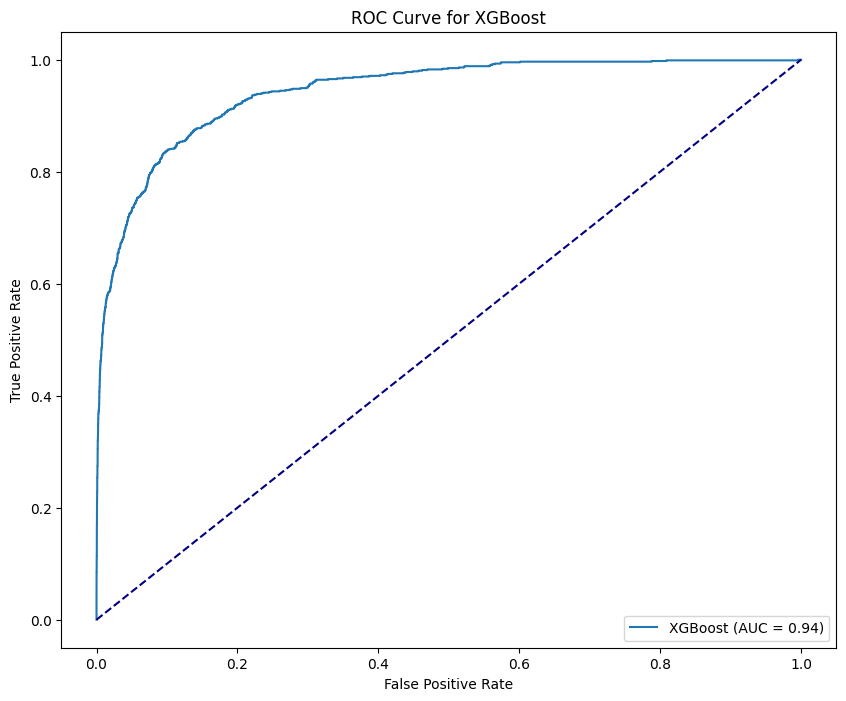

In [3]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt
from itertools import product

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Dividir datos para entrenar y validar
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Definir los rangos de hiperparámetros
param_grid = {
    'learning_rate': np.arange(0.1, 0.31, 0.05),
    'reg_lambda': np.arange(3.5, 4.51, 0.1),
    'n_estimators': list(range(190, 201, 1))
}

# Obtener todas las combinaciones de hiperparámetros
param_combinations = list(product(param_grid['learning_rate'], param_grid['reg_lambda'], param_grid['n_estimators']))

# Contar el número de combinaciones de hiperparámetros
total_combinations = len(param_combinations)
print(f"Se probarán {total_combinations} combinaciones de hiperparámetros.")

best_log_loss = float('inf')
best_params = None
progress = 0

# DataFrame para almacenar resultados
results_df = pd.DataFrame(columns=['learning_rate', 'reg_lambda', 'n_estimators', 'log_loss'])

# Probar cada combinación de hiperparámetros sin validación cruzada
for learning_rate, reg_lambda, n_estimators in param_combinations:
    progress += 1
    print(f"Probando combinación {progress}/{total_combinations}: "
          f"learning_rate={learning_rate}, reg_lambda={reg_lambda}, n_estimators={n_estimators}")

    # Definir el modelo con los hiperparámetros actuales
    xgb_model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        learning_rate=learning_rate,
        reg_lambda=reg_lambda,
        n_estimators=n_estimators
    )

    # Entrenar el modelo
    xgb_model.fit(X_train, y_train)

    # Predicción en el conjunto de validación
    y_val_proba = xgb_model.predict_proba(X_val)[:, 1]

    # Cálculo de la métrica log loss
    log_loss_val = log_loss(y_val, y_val_proba)

    # Guardar los resultados en el DataFrame si no tienen valores NaN
    new_row = pd.DataFrame({
        'learning_rate': [learning_rate],
        'reg_lambda': [reg_lambda],
        'n_estimators': [n_estimators],
        'log_loss': [log_loss_val]
    })

    if not new_row.isna().any().any():  # Asegurarse de que no haya valores vacíos
        results_df = pd.concat([results_df, new_row], ignore_index=True)

    # Verificar si es el mejor modelo
    if log_loss_val < best_log_loss:
        best_log_loss = log_loss_val
        best_params = {
            'learning_rate': learning_rate,
            'reg_lambda': reg_lambda,
            'n_estimators': n_estimators
        }

    print(f"Log Loss para esta combinación: {log_loss_val:.4f}\n")

# Mostrar los mejores hiperparámetros y el mejor log_loss
print(f"Mejores parámetros encontrados: {best_params}")
print(f"Mejor Log Loss: {best_log_loss:.4f}")

# Guardar los resultados en un archivo CSV (opcional)
results_df.to_csv('resultados_hyperparametros.csv', index=False)

# Entrenar el mejor modelo con los mejores hiperparámetros
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    learning_rate=best_params['learning_rate'],
    reg_lambda=best_params['reg_lambda'],
    n_estimators=best_params['n_estimators']
)

xgb_model.fit(X_train, y_train)

# Predicción final en el conjunto de validación
y_val_proba = xgb_model.predict_proba(X_val)[:, 1]
y_val_pred = xgb_model.predict(X_val)

# Cálculo de la métrica log loss
log_loss_val = log_loss(y_val, y_val_proba)
print(f"Log Loss final con los mejores hiperparámetros: {log_loss_val:.4f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y_val, y_val_pred)
print("Matriz de confusión:")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y_val, y_val_pred)
print(f"Accuracy: {accuracy:.4f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y_val, y_val_proba)
roc_auc = auc(fpr, tpr)
print(f"AUC: {roc_auc:.4f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost')
plt.legend(loc='lower right')
plt.show()

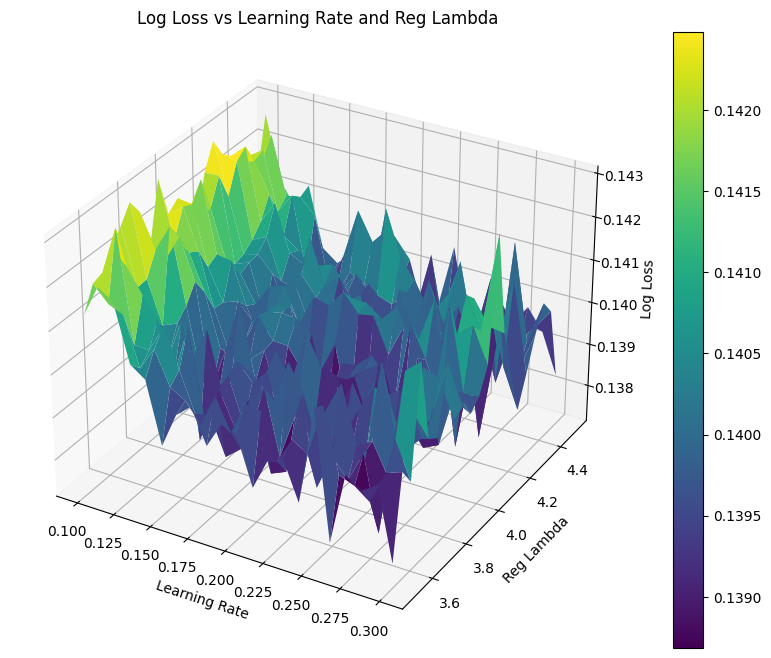

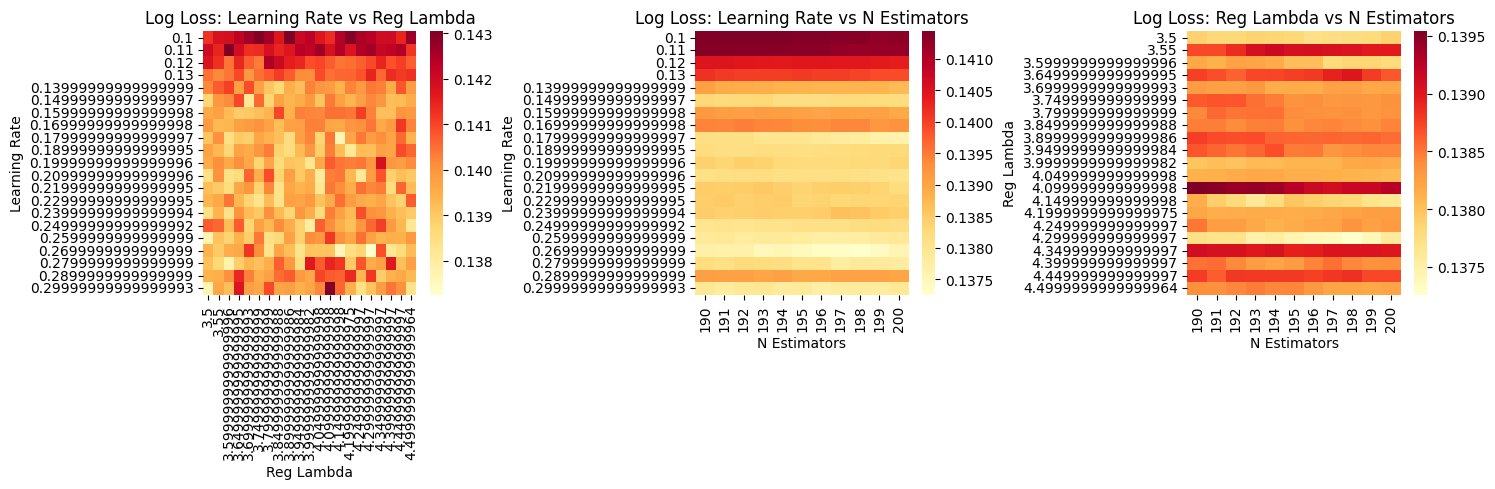

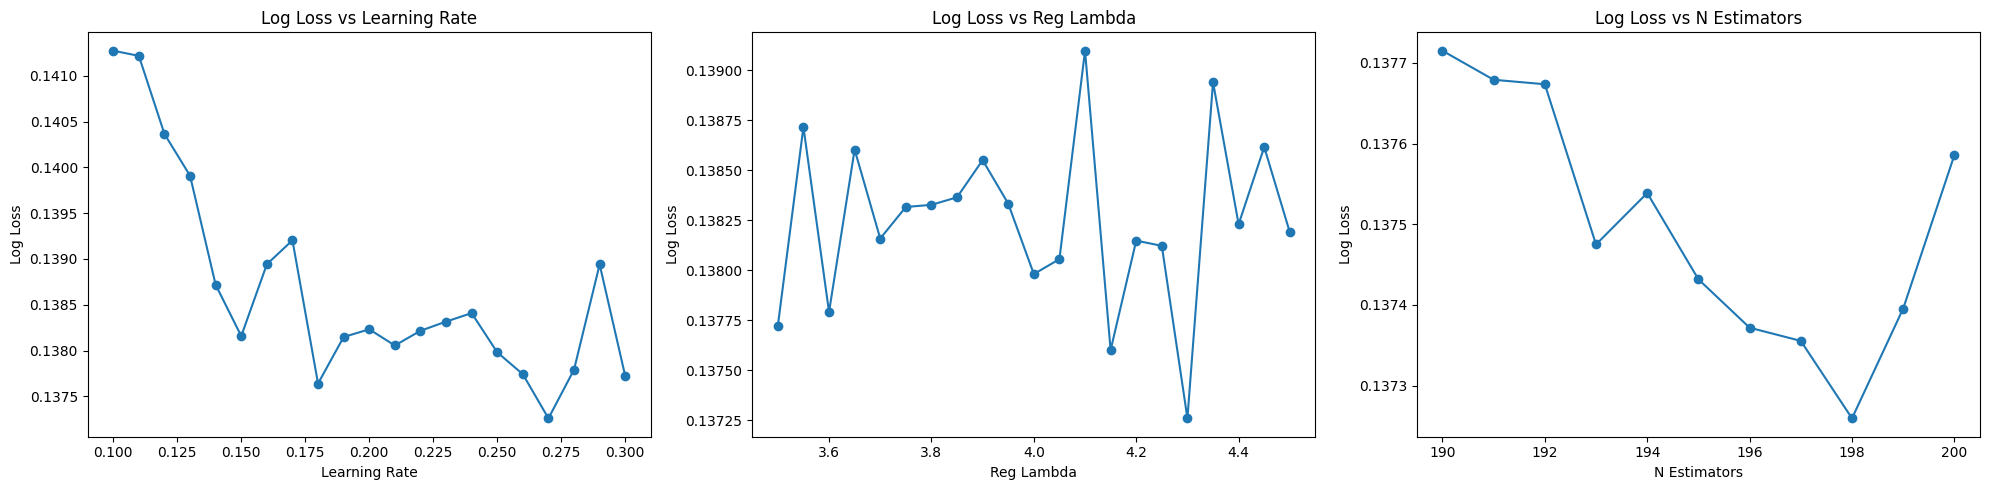

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns

# Asumimos que results_df es el DataFrame que contiene los resultados obtenidos previamente
# Columnas: 'learning_rate', 'reg_lambda', 'n_estimators', 'log_loss'

# Extraer los valores únicos de los hiperparámetros
learning_rates = sorted(results_df['learning_rate'].unique())
reg_lambdas = sorted(results_df['reg_lambda'].unique())
n_estimators = sorted(results_df['n_estimators'].unique())

# Convertir los resultados de log loss
logloss_scores = results_df['log_loss'].values

# 1. Gráfico de superficie 3D: Log Loss vs Learning Rate y Reg Lambda
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

X, Y = np.meshgrid(learning_rates, reg_lambdas)
Z = np.zeros_like(X)

for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        Z[j, i] = results_df[(results_df['learning_rate'] == lr) & (results_df['reg_lambda'] == reg)]['log_loss'].min()

surf = ax.plot_surface(X, Y, Z, cmap='viridis')
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Reg Lambda')
ax.set_zlabel('Log Loss')
ax.set_title('Log Loss vs Learning Rate and Reg Lambda')
fig.colorbar(surf)
plt.show()

# 2. Heatmaps
plt.figure(figsize=(15, 5))

# Learning Rate vs Reg Lambda
plt.subplot(131)
heatmap_data = np.zeros((len(learning_rates), len(reg_lambdas)))
for i, lr in enumerate(learning_rates):
    for j, reg in enumerate(reg_lambdas):
        heatmap_data[i, j] = results_df[(results_df['learning_rate'] == lr) & (results_df['reg_lambda'] == reg)]['log_loss'].min()
sns.heatmap(heatmap_data, xticklabels=reg_lambdas, yticklabels=learning_rates, cmap='YlOrRd')
plt.xlabel('Reg Lambda')
plt.ylabel('Learning Rate')
plt.title('Log Loss: Learning Rate vs Reg Lambda')

# Learning Rate vs N Estimators
plt.subplot(132)
heatmap_data = np.zeros((len(learning_rates), len(n_estimators)))
for i, lr in enumerate(learning_rates):
    for j, n in enumerate(n_estimators):
        heatmap_data[i, j] = results_df[(results_df['learning_rate'] == lr) & (results_df['n_estimators'] == n)]['log_loss'].min()
sns.heatmap(heatmap_data, xticklabels=n_estimators[::1], yticklabels=learning_rates, cmap='YlOrRd')
plt.xlabel('N Estimators')
plt.ylabel('Learning Rate')
plt.title('Log Loss: Learning Rate vs N Estimators')

# Reg Lambda vs N Estimators
plt.subplot(133)
heatmap_data = np.zeros((len(reg_lambdas), len(n_estimators)))
for i, reg in enumerate(reg_lambdas):
    for j, n in enumerate(n_estimators):
        heatmap_data[i, j] = results_df[(results_df['reg_lambda'] == reg) & (results_df['n_estimators'] == n)]['log_loss'].min()
sns.heatmap(heatmap_data, xticklabels=n_estimators[::1], yticklabels=reg_lambdas, cmap='YlOrRd')
plt.xlabel('N Estimators')
plt.ylabel('Reg Lambda')
plt.title('Log Loss: Reg Lambda vs N Estimators')

plt.tight_layout()
plt.show()

# 3. Gráficos de línea
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# Learning Rate
lr_scores = [results_df[results_df['learning_rate'] == lr]['log_loss'].min() for lr in learning_rates]
ax1.plot(learning_rates, lr_scores, marker='o')
ax1.set_xlabel('Learning Rate')
ax1.set_ylabel('Log Loss')
ax1.set_title('Log Loss vs Learning Rate')

# Reg Lambda
reg_scores = [results_df[results_df['reg_lambda'] == reg]['log_loss'].min() for reg in reg_lambdas]
ax2.plot(reg_lambdas, reg_scores, marker='o')
ax2.set_xlabel('Reg Lambda')
ax2.set_ylabel('Log Loss')
ax2.set_title('Log Loss vs Reg Lambda')

# N Estimators
n_scores = [results_df[results_df['n_estimators'] == n]['log_loss'].min() for n in n_estimators]
ax3.plot(n_estimators, n_scores, marker='o')
ax3.set_xlabel('N Estimators')
ax3.set_ylabel('Log Loss')
ax3.set_title('Log Loss vs N Estimators')

plt.tight_layout()
plt.show()

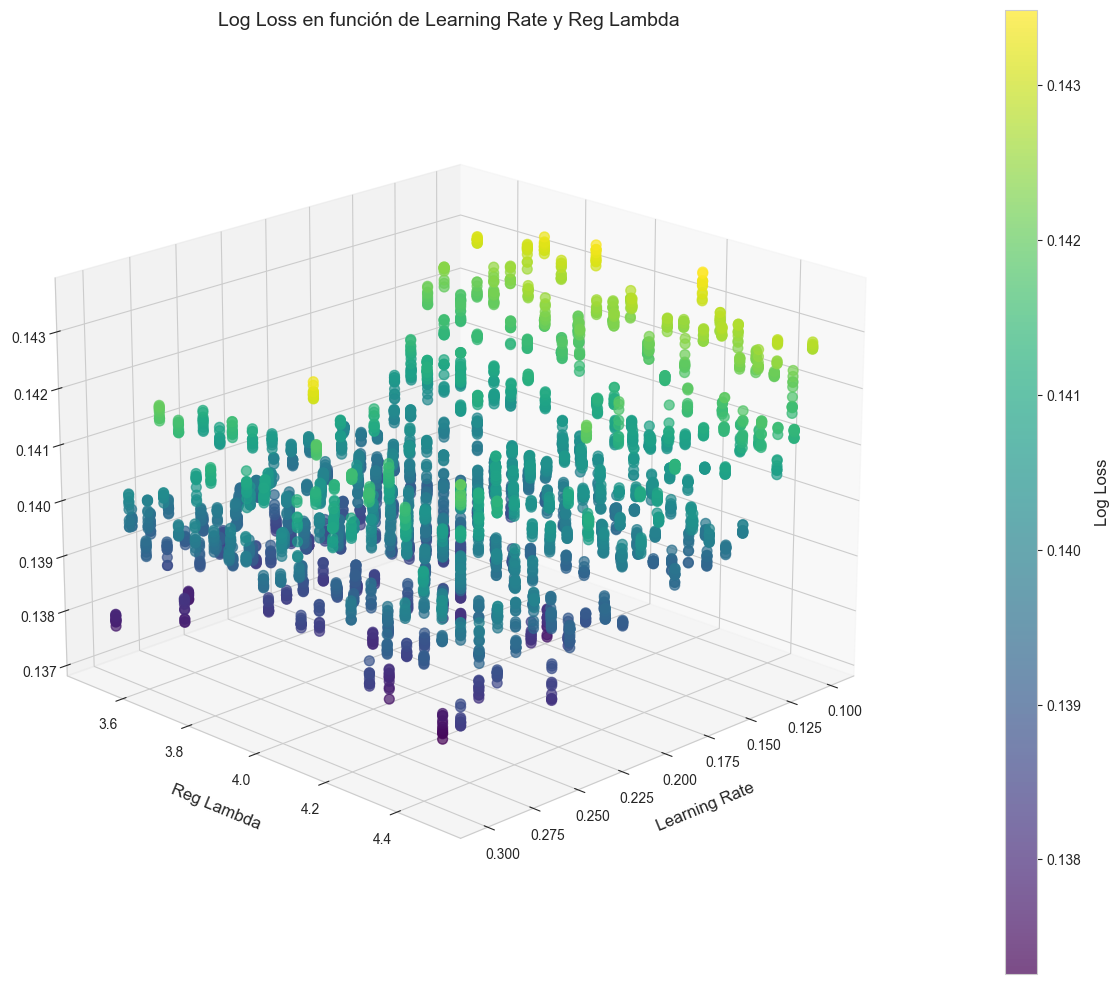

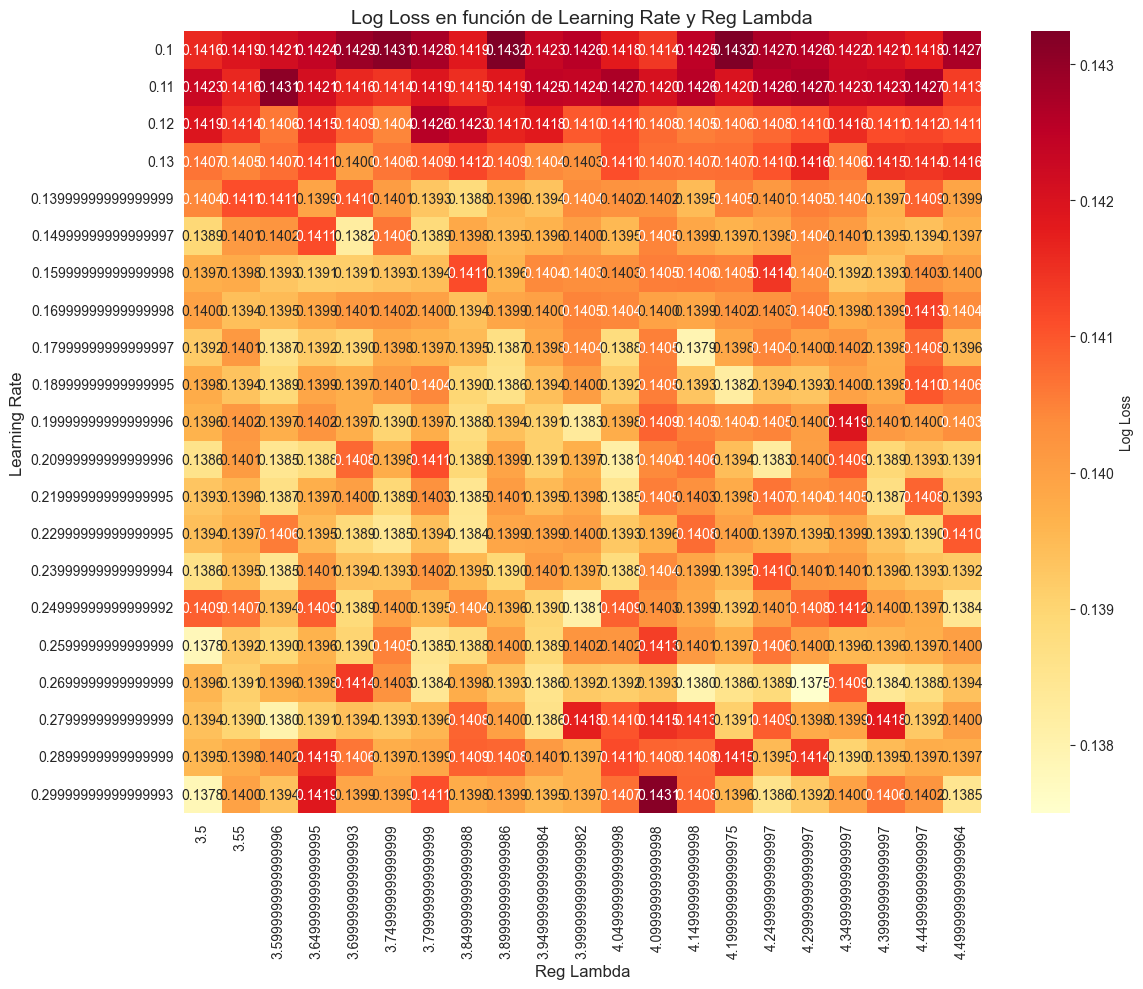

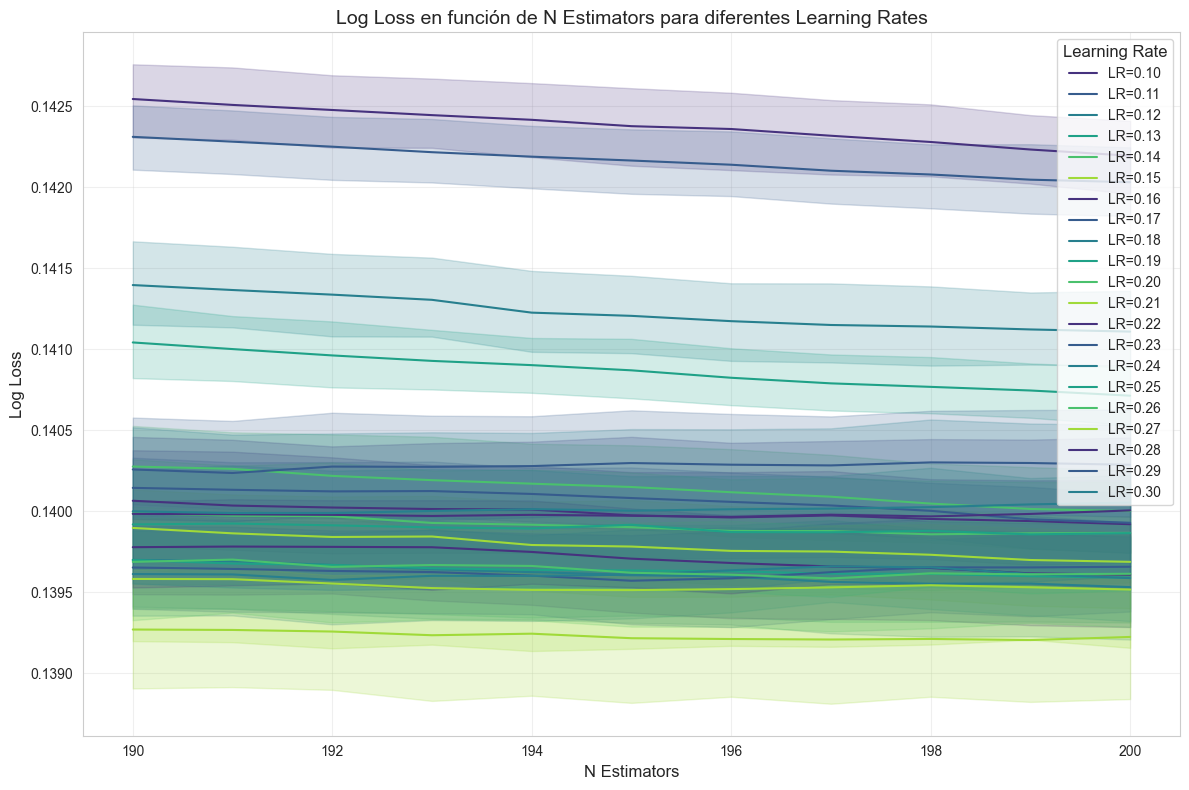

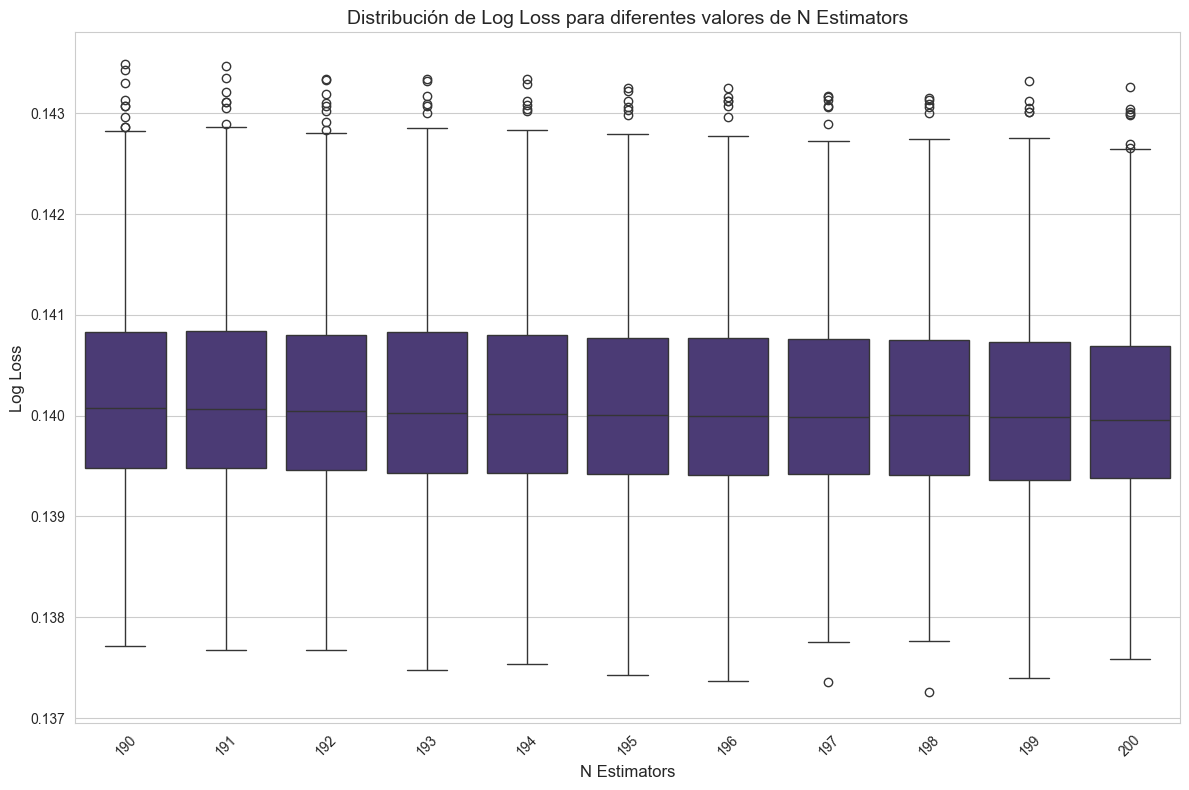

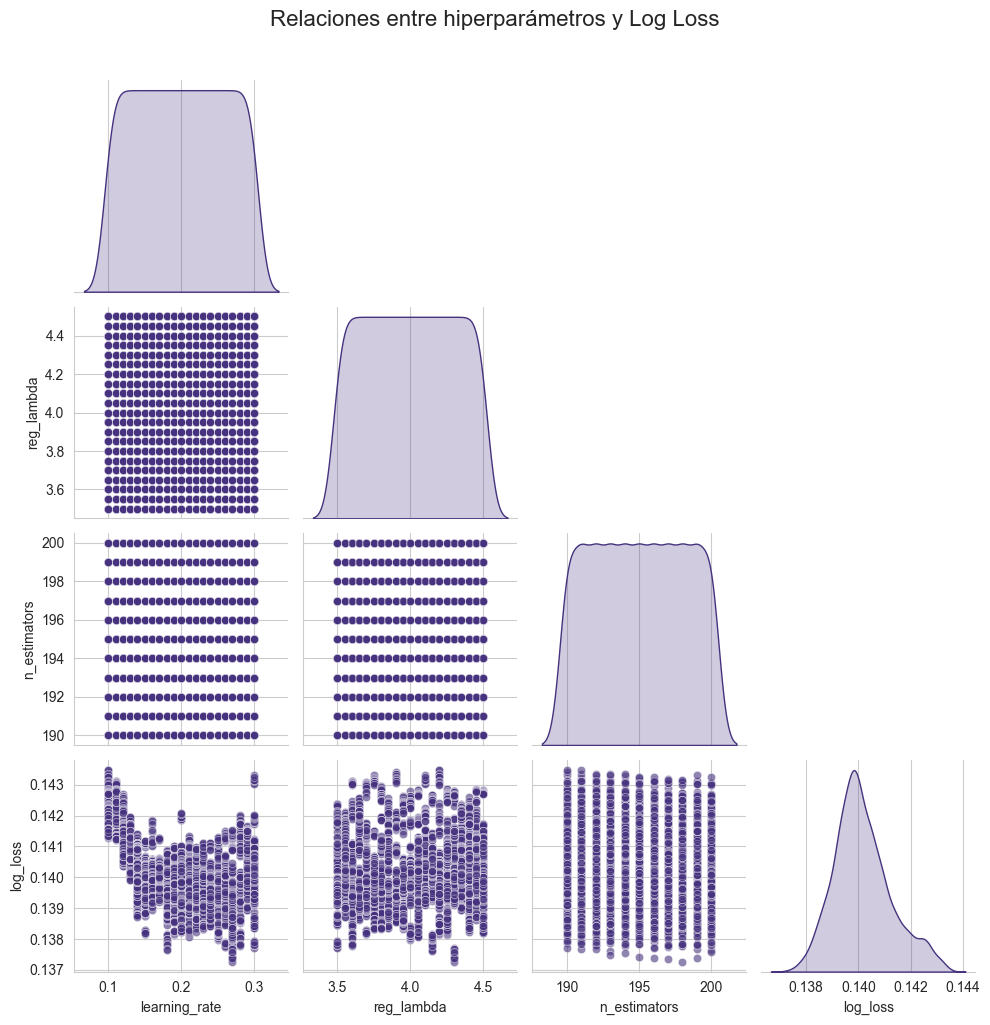


Mejores hiperparámetros encontrados:
Learning Rate: 0.2700
Reg Lambda: 4.3000
N Estimators: 198
Log Loss: 0.1373


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Aquí asumimos que 'results_df' ya contiene los resultados de los experimentos de hiperparámetros:
# 'learning_rate', 'reg_lambda', 'n_estimators', 'log_loss'

# Configuración del estilo de seaborn
sns.set_style("whitegrid")
sns.set_palette("viridis")

# Visualización 1: Gráfica 3D mejorada de learning_rate, reg_lambda y log_loss
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(results_df['learning_rate'], 
                     results_df['reg_lambda'], 
                     results_df['log_loss'], 
                     c=results_df['log_loss'], 
                     cmap='viridis', 
                     s=50, 
                     alpha=0.7)

ax.set_xlabel('Learning Rate', fontsize=12, labelpad=10)
ax.set_ylabel('Reg Lambda', fontsize=12, labelpad=10)
ax.set_zlabel('Log Loss', fontsize=12, labelpad=10)

cbar = fig.colorbar(scatter, ax=ax, pad=0.1, aspect=30)
cbar.set_label('Log Loss', fontsize=12, labelpad=10)

ax.set_title('Log Loss en función de Learning Rate y Reg Lambda', fontsize=14, pad=20)

# Rotar la vista para una mejor perspectiva
ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

# Visualización 2: Heatmap de Log Loss en función de Learning Rate y Reg Lambda
plt.figure(figsize=(12, 10))
pivot_table = results_df.pivot_table(values='log_loss', 
                                     index='learning_rate', 
                                     columns='reg_lambda', 
                                     aggfunc='mean')

sns.heatmap(pivot_table, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Log Loss'})
plt.title('Log Loss en función de Learning Rate y Reg Lambda', fontsize=14)
plt.xlabel('Reg Lambda', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.tight_layout()
plt.show()

# Visualización 3: Gráfica de líneas mejorada de n_estimators y log_loss
plt.figure(figsize=(12, 8))

for lr in sorted(results_df['learning_rate'].unique()):
    subset = results_df[results_df['learning_rate'] == lr]
    sns.lineplot(x='n_estimators', y='log_loss', data=subset, label=f'LR={lr:.2f}')

plt.xlabel('N Estimators', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Log Loss en función de N Estimators para diferentes Learning Rates', fontsize=14)
plt.legend(title='Learning Rate', title_fontsize='12', fontsize='10')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Visualización 4: Box plot de Log Loss para diferentes valores de N Estimators
plt.figure(figsize=(12, 8))
sns.boxplot(x='n_estimators', y='log_loss', data=results_df)
plt.xlabel('N Estimators', fontsize=12)
plt.ylabel('Log Loss', fontsize=12)
plt.title('Distribución de Log Loss para diferentes valores de N Estimators', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Visualización 5: Pair plot para todas las variables
sns.pairplot(results_df, vars=['learning_rate', 'reg_lambda', 'n_estimators', 'log_loss'], 
             corner=True, diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Relaciones entre hiperparámetros y Log Loss', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Imprimir los mejores hiperparámetros
best_params = results_df.loc[results_df['log_loss'].idxmin()]
print("\nMejores hiperparámetros encontrados:")
print(f"Learning Rate: {best_params['learning_rate']:.4f}")
print(f"Reg Lambda: {best_params['reg_lambda']:.4f}")
print(f"N Estimators: {best_params['n_estimators']}")
print(f"Log Loss: {best_params['log_loss']:.4f}")

## Verificar con Cross Validation

Log Loss (CV): 0.137053
Matriz de confusión (CV):
[[48061   586]
 [ 1934  2400]]
Accuracy (CV): 0.952436
AUC (CV): 0.946699


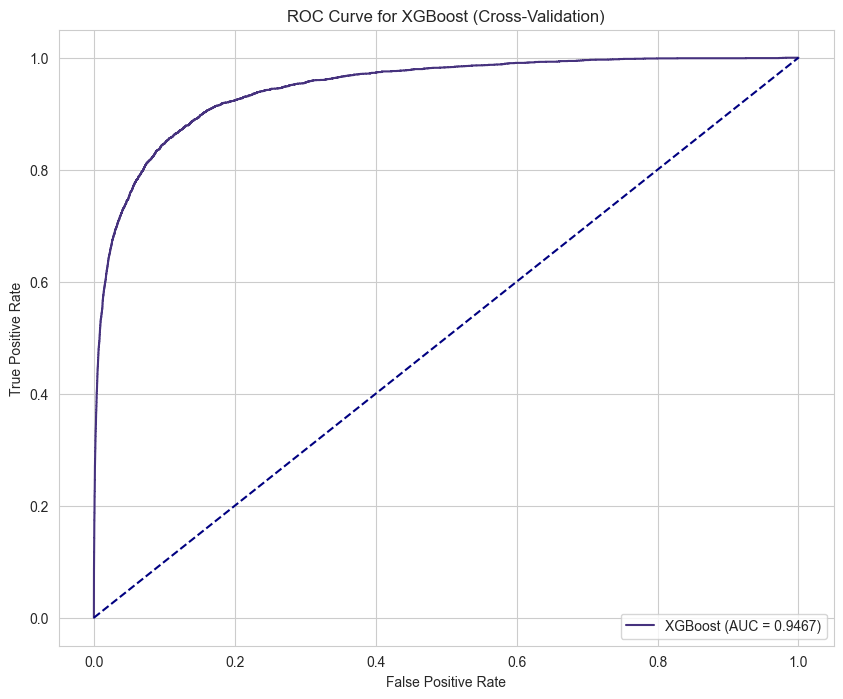

In [6]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.metrics import roc_curve, auc, accuracy_score, confusion_matrix, log_loss
import matplotlib.pyplot as plt

# Cargar los datos
data = pd.read_csv('hoteles-entrena-limpio-normalizado.csv')
X = data.drop(columns=['children'])
y = data['children']

# Definir el modelo de XGBoost con los hiperparámetros fijos
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    max_depth=9,
    learning_rate=0.27,
    reg_lambda=4.3,
    n_estimators=198
)

# Definir la validación cruzada con StratifiedKFold (5 folds)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Realizar predicciones con validación cruzada
y_pred_proba_cv = cross_val_predict(xgb_model, X, y, cv=cv, method='predict_proba')[:, 1]
y_pred_cv = cross_val_predict(xgb_model, X, y, cv=cv)

# Cálculo de las métricas usando validación cruzada
log_loss_cv = log_loss(y, y_pred_proba_cv)
print(f"Log Loss (CV): {log_loss_cv:.6f}")

# Matriz de confusión
conf_matrix = confusion_matrix(y, y_pred_cv)
print("Matriz de confusión (CV):")
print(conf_matrix)

# Exactitud (accuracy)
accuracy = accuracy_score(y, y_pred_cv)
print(f"Accuracy (CV): {accuracy:.6f}")

# Curva ROC y AUC
fpr, tpr, _ = roc_curve(y, y_pred_proba_cv)
roc_auc = auc(fpr, tpr)
print(f"AUC (CV): {roc_auc:.6f}")

# Graficar la curva ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for XGBoost (Cross-Validation)')
plt.legend(loc='lower right')
plt.show()